In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
import tensorflow as tf


# LOAD DATASET

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0


# Creating Models

In [19]:
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(128, activation='relu'),

        tf.keras.layers.Dense(64, activation='relu'),

        tf.keras.layers.Dense(10, activation='softmax')
    ])

    return model

#  MODEL WITH MOMENTUM

In [20]:
model_momentum = create_model()


# Here we are setting up our optimizer to be momentum
optimizer_momentum = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.6
)


# Compiling the model and using momentum as the optimizer which is defined above 
model_momentum.compile(
    optimizer=optimizer_momentum,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training using Momentum...")

history_momentum = model_momentum.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=1024,
    validation_split=0.1
)


Training using Momentum...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3810 - loss: 2.0380 - val_accuracy: 0.6540 - val_loss: 1.6940
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6994 - loss: 1.4213 - val_accuracy: 0.8022 - val_loss: 1.0567
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7964 - loss: 0.9273 - val_accuracy: 0.8527 - val_loss: 0.6982
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8316 - loss: 0.6888 - val_accuracy: 0.8768 - val_loss: 0.5396
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8513 - loss: 0.5742 - val_accuracy: 0.8898 - val_loss: 0.4570
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8640 - loss: 0.5081 - val_accuracy: 0.8963 - val_loss: 0.4071
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8741 - loss: 0.4646 - val_accuracy: 0.9032 - val_loss: 0.3725
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8809 - loss: 0.4334

In [21]:
# MODEL WITH NAG


model_nag = create_model()


# Setting up the NAG optimier to be used further
optimizer_nag = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.6,
    nesterov=True
)

# Compiling the model and using NAG as the optimizer which is defined above 

model_nag.compile(
    optimizer=optimizer_nag,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training using NAG...")

history_nag = model_nag.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=1024,
    validation_split=0.1
)


Training using NAG...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3506 - loss: 2.0521 - val_accuracy: 0.5898 - val_loss: 1.6591
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6928 - loss: 1.3406 - val_accuracy: 0.8102 - val_loss: 0.9816
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8076 - loss: 0.8655 - val_accuracy: 0.8690 - val_loss: 0.6558
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8437 - loss: 0.6515 - val_accuracy: 0.8868 - val_loss: 0.5080
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8630 - loss: 0.5454 - val_accuracy: 0.8967 - val_loss: 0.4309
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8746 - loss: 0.4837 - val_accuracy: 0.9035 - val_loss: 0.3836
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8819 - loss: 0.4433 - val_accuracy: 0.9072 - val_loss: 0.3537
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8875 - loss: 0.4149 - va

In [22]:
# 5. TEST BOTH MODELS


loss_momentum, acc_momentum = model_momentum.evaluate(
    x_test,
    y_test,
    verbose=0
)

loss_nag, acc_nag = model_nag.evaluate(
    x_test,
    y_test,
    verbose=0
)


In [23]:
# 6. PRINT RESULTS

print("Momentum Accuracy:",
      acc_momentum * 100, "%")

print("NAG Accuracy:",
      acc_nag * 100, "%")

Momentum Accuracy: 90.9600019454956 %
NAG Accuracy: 91.39999747276306 %


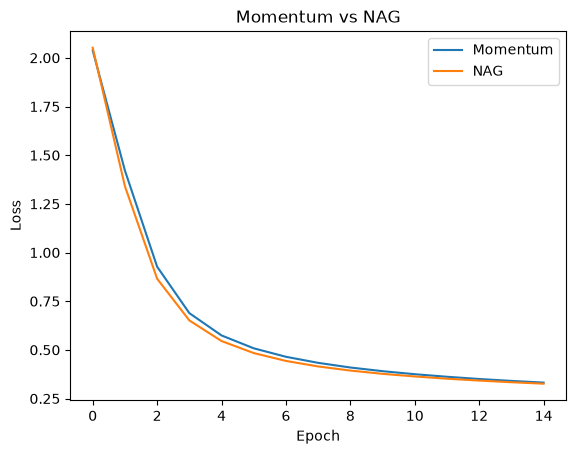

In [24]:
plt.plot(
    history_momentum.history['loss'],
    label='Momentum'
)

plt.plot(
    history_nag.history['loss'],
    label='NAG'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Momentum vs NAG")

plt.legend()
plt.show()